# EDA Notebook

We will use this notebook to evaluate and process our data from the CSV files.

In [37]:
print("Hello, Vibetastrophe Consulting!")

Hello, Vibetastrophe Consulting!


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Import CSV files into pandas

We will import the csv from the `data/raw/smart_city_csvs` folder.

In [39]:
city_df = pd.read_csv('../data/raw/smart_city_csvs/city_traffic_accidents.csv')

urban_df = pd.read_csv('../data/raw/smart_city_csvs/urbanpulse_311_complaints.csv')


In [40]:
city_df.head(10)

# Initial look @ the city traffic accidents df.
# 500,001 Rowx and 46 columns
# ID & Source columns unnecessary ?

# Severity column(Label Encode?)

# Maybe only need the Distance column instead of the Lat&Lng columns
# True/Fals Columns = Possibly Encode(Roundabout, station, traffic_calming, traffic_signal, turning_loop, 
#                                    amenity, bump, crossing, give_way, junction, no_exit, railway, stop,) 
                                    
# Day/Night columns = Possibly Encode(Sunrise_Sunset, Civil_twilight, Nautical_Twilight, Astonomical_twilight)

# Weather_Condition column (Maybe One-Hot Encoding)
# Timezone column (Maybe One-Hot Encoding)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1784167,Source2,2,2019-10-29 13:16:54,2019-10-29 15:21:34,35.834797,-78.638512,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-862811,Source2,2,2021-10-13 06:30:00,2021-10-13 06:59:15,36.088970,-96.011734,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-4054572,Source1,2,2022-08-14 14:42:58,2022-08-14 16:27:58,33.537049,-86.794445,33.535373,-86.796156,0.152,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-6147589,Source1,2,2021-06-25 19:13:44,2021-06-25 20:42:30,34.071722,-117.612886,34.078917,-117.625339,0.869,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-5025169,Source1,2,2022-03-18 12:50:30,2022-03-18 13:13:00,40.324235,-76.790464,40.322625,-76.788114,0.166,...,False,False,False,False,False,False,Day,Day,Day,Day
5,A-4007360,Source1,2,2022-11-16 05:22:30.000000,2022-11-16 08:04:30.000000,34.024005,-117.557851,34.029942,-117.579011,1.279,...,False,False,False,False,False,False,Night,Night,Night,Day
6,A-2185422,Source2,2,2019-04-24 07:25:21,2019-04-24 08:25:01,34.136070,-80.880547,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
7,A-94012,Source2,2,2016-08-31 11:14:13,2016-08-31 11:44:13,34.245651,-118.874870,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
8,A-6717568,Source1,2,2020-10-24 20:15:00,2020-10-24 22:19:12,38.671507,-120.566459,38.671875,-120.566081,0.033,...,False,False,False,False,False,False,Night,Night,Night,Night
9,A-2960129,Source2,2,2018-03-21 20:44:14,2018-03-21 21:14:06,30.413244,-97.690582,NaN,NaN,0.000,...,False,False,False,False,True,False,Night,Night,Night,Day


In [41]:
urban_df.head()

# NLP Perspective!!!
# Initial Look @ the 311 complaints df.
# 434,723 Rows & 11 Columns

# Unique_Key, Created_date, Closed_date, agency & agency_name columns all unnecessary

# Complaint_type (One-Hot Encoding Top 5 categories and 1 "Other" Category) TARGET

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed


In [42]:
urban_df.isnull().sum()

# For the 311 Complaints df we have:
# Only 2 columns will missing values
# 50,000 Null Values under closed_date column

# 3,675 Null values under the descriptor column

# Not alot of valuable missing data in this dataset.


unique_key                    0
created_date                  0
closed_date               50080
agency                        0
agency_name                   0
complaint_type                0
descriptor                 3675
resolution_description        0
borough                       0
open_data_channel_type        0
status                        0
dtype: int64

In [43]:
city_df.isnull().sum()

# We have alot more missing values in this dataset, how will we handle them?

# 21 Total columns with Null/missing values
# Columns with high missing value counts > 10% = End_Lat&Lng, Wind_chill, Precipitaion


ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  219978
End_Lng                  219978
Distance(mi)                  0
Description                   0
Street                      654
City                         28
County                        0
State                         0
Zipcode                     118
Country                       0
Timezone                    476
Airport_Code               1514
Weather_Timestamp          7842
Temperature(F)            10700
Wind_Chill(F)            129188
Humidity(%)               11371
Pressure(in)               9170
Visibility(mi)            11482
Wind_Direction            11382
Wind_Speed(mph)           36902
Precipitation(in)        142366
Weather_Condition         11300
Amenity                       0
Bump                          0
Crossing

In [44]:
TARGET_city = city_df['Severity']
TARGET_values = TARGET_city.value_counts()

TARGET_perc = TARGET_city.value_counts(normalize=True) * 100

print(f"Class Distribution: {TARGET_values}")
print(f"Class Percentages: {TARGET_perc}")

# The accident severity TARGET has significant class imbalance
# Nearly 80% represents Severity 2
# Only 2% represents Severity 4
# Less than 1% represents Severity 1

Class Distribution: Severity
2    398335
3     84063
4     13244
1      4358
Name: count, dtype: int64
Class Percentages: Severity
2    79.6670
3    16.8126
4     2.6488
1     0.8716
Name: proportion, dtype: float64


Text(0, 0.5, 'Count')

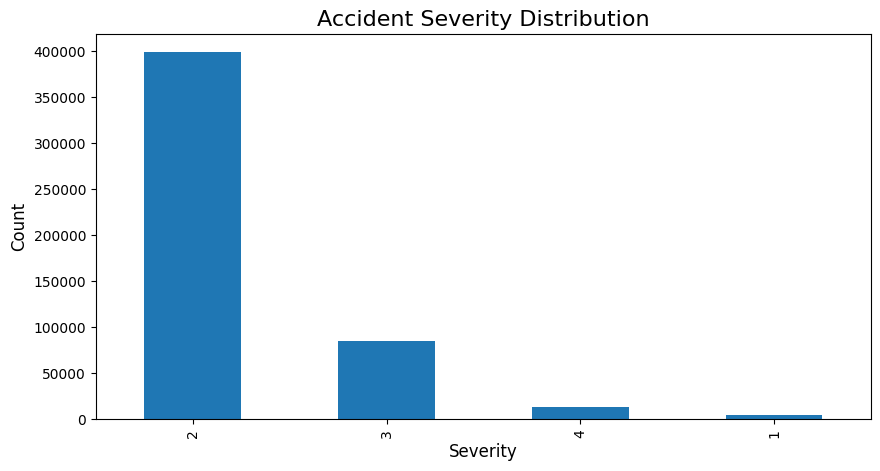

In [ ]:
# Creating a bar chart of the Accident Severity categories.
# Cleearly we can visualize the "Severity" of the class imbalance in our TARGET.
plt.figure(figsize=(10, 5))
plt.title("Accident Severity Distribution", fontsize=16)

city_df['Severity'].value_counts().plot(kind='bar')
plt.xlabel("Severity", fontsize=12)
plt.ylabel("Count", fontsize=12)

In [ ]:
TARGET_urban = urban_df['complaint_type']
TARGET_urban_val = TARGET_urban.value_counts()

print(f"{TARGET_urban_val}")

# Client meeting said 186 complaint categories as reflected here
# Top 5 categories: "Illegal Parking" (66,159 complaints)
# "HEAT/HOT WATER" (64,362 complaints)
# "Noise - Residential" (38,931 complaints)
# "Snow or Ice" (27,453 complaints)
# " Blocked Driveway"(24,920 complaints)
# Everything else we will ceate and put into the 'OTHER" category

complaint_type
Illegal Parking                   66159
HEAT/HOT WATER                    64362
Noise - Residential               38931
Snow or Ice                       27453
Blocked Driveway                  24920
                                  ...  
Illegal Animal Sold                   2
Found Property                        1
Building Marshal's Office             1
Institution Disposal Complaint        1
Dept of Investigations                1
Name: count, Length: 151, dtype: int64


## Going to Map the complaint categories so we can visualize the distribution.

In [48]:
def create_complaint_categories(df: pd.DataFrame) -> pd.DataFrame:
   
    top_5 = ['Illegal Parking', 'HEAT/HOT WATER', 'Noise - Residential',
             'Snow or Ice', 'Blocked Driveway']
    df['complaint_category'] = df['complaint_type'].apply(
        lambda x: x if x in top_5 else 'Other'
    )

    print("Complaint category distribution:")
    print(df['complaint_category'].value_counts())

    coverage = df[df['complaint_category'] != 'Other'].shape[0] / len(df) * 100
    print(f"\nTop 5 categories cover {coverage:.1f}% of all complaints")
    print(f"Total classes: {df['complaint_category'].nunique()} (top 5 + Other)")

    return df

In [49]:
urban_copy = urban_df.copy()            # Just going to make a copy so i dont modify the original dataframe
create_complaint_categories(urban_copy)

Complaint category distribution:
complaint_category
Other                  212897
Illegal Parking         66159
HEAT/HOT WATER          64362
Noise - Residential     38931
Snow or Ice             27453
Blocked Driveway        24920
Name: count, dtype: int64

Top 5 categories cover 51.0% of all complaints
Total classes: 6 (top 5 + Other)


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status,complaint_category
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed,HEAT/HOT WATER
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed,Other
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed,Illegal Parking
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed,HEAT/HOT WATER
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed,Illegal Parking
...,...,...,...,...,...,...,...,...,...,...,...,...
434717,68070299,2026-02-21T22:32:39.000,2026-02-21T23:05:06.000,NYPD,New York City Police Department,Noise - Vehicle,Car/Truck Horn,The New York City Police Department responded ...,MANHATTAN,MOBILE,Closed,Other
434718,67963040,2026-02-11T06:48:19.000,2026-02-12T06:27:55.000,DSNY,Department of Sanitation,Dirty Condition,Trash,The Department of Sanitation investigated this...,STATEN ISLAND,ONLINE,Closed,Other
434719,68202250,2026-03-04T11:55:42.000,2026-03-06T20:08:12.000,HPD,Department of Housing Preservation and Develop...,ELECTRIC,WIRING,HPD attempted to conduct an inspection in resp...,BRONX,PHONE,Closed,Other
434720,68187203,2026-03-02T23:25:44.000,2026-03-03T12:41:37.000,NYPD,New York City Police Department,Abandoned Vehicle,With License Plate,The New York City Police Department responded ...,QUEENS,ONLINE,Closed,Other


Text(0, 0.5, 'Count')

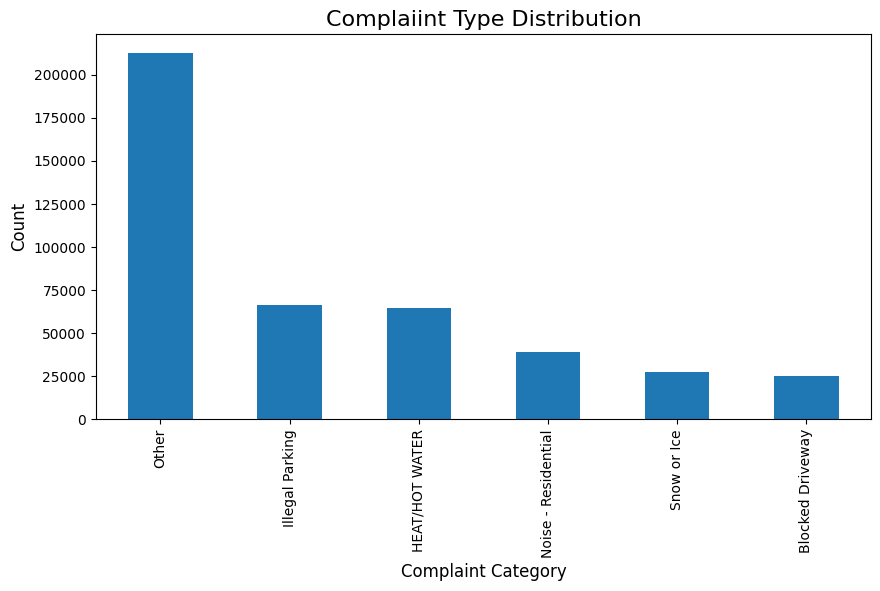

In [51]:
plt.figure(figsize=(10, 5))
plt.title("Complaiint Type Distribution", fontsize=16)

urban_copy['complaint_category'].value_counts().plot(kind='bar')
plt.xlabel("Complaint Category", fontsize=12)
plt.ylabel("Count", fontsize=12)

### NLP(Natural Language Processing) Section: Predicting the Complaint_Type using the Resolution_Decription text field, Let's take a look at the text in that column.

In [ ]:
resolution_text = urban_df['resolution_description']
resolution_text.head(15)

# Intial Look at the resolution_description column:
# Text looks clean and well formatted
# i see no spelling errors or slang words in the initial look at the ttext data
# We do have abbreviations like "HPD", "DEP", and website links as well as phone numbers.

0     This complaint is a duplicate of a building-wi...
1     HPD conducted an inspection of this complaint....
2     The New York City Police Department responded ...
3     HPD responded to a complaint of no heat or hot...
4     The New York City Police Department responded ...
5     The New York City Police Department responded ...
6     The New York City Police Department responded ...
7     This complaint is a duplicate of a building-wi...
8     HPD responded to a complaint of no heat or hot...
9     The Department of Health and Mental Hygiene ha...
10    The Department of Environmental Protection (DE...
11    The Department of Housing Preservation and Dev...
12    The New York City Police Department responded ...
13    The New York City Police Department responded ...
14    HPD conducted an inspection of this complaint....
Name: resolution_description, dtype: object

In [ ]:
resolution_text.value_counts()

# looking at the value counts for the resolution description column, the most common resolution is "No Action Taken" (117,000 complaints)
# The next most common resolution is "Closed with Explanation" (82,000 complaints)  
# The third most common resolution is "Closed" (66,000 complaints)
# The fourth most common resolution is "Closed with Enforcement" (50,000 complaints)

resolution_description
The New York City Police Department responded to the complaint and their investigation determined that no criminal violation existed. The condition was corrected without the need to issue a summons or effect an arrest. If the problem persists, please contact 311 to create another complaint. If possible, provide contact information so responding officers may reach out to you for more details. If necessary, your complaint may be referred to your local precinct's special operations units (Quality of Life, etc.). Thank you for your attention to this matter. We count on New Yorkers like yourself to maintain a safe City, so please let us know if you see other conditions that require our attention.    36960
The New York City Police Department responded to the complaint and with the information available observed no evidence of a criminal violation at that time. If the problem persists, please contact 311 to create another complaint. If possible, provide contact informat

## Attention is all you need, we know what makes BERT special!!
### My hypothesis is that BERT will perform best for this task due to its use of the encoder side of the transformer architecture.
### Once we get our data cleaned up and pre processed I will start with traditional NLP techniques to get a baseline and then progress to Transformers